# CFU prediction using TPM values from bulk RNA-seq

## Data loading

Configure root with local/colab.

In [ ]:
import sys, subprocess
import numpy as np
%matplotlib inline
from pathlib import Path

# Configure root
COLAB = Path("/content").exists()
repo_url = "https://github.com/eddykang06/phenotype-prediction.git"
repo_dir = Path("phenotype-prediction")
if COLAB:
    root = Path("/content/phenotype-prediction")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", repo_url])
else:
    root = Path.cwd().parent
sys.path.insert(0, str(root))

Configure data path for colab/local.

In [ ]:
if COLAB:
  from google.colab import drive
  drive.mount("/content/drive")
  data_dir = Path("/content/drive/MyDrive/phenotype-prediction-data")
  fcnts_path = str(data_dir / "fcnts_timezero")
  cfu_path = str(data_dir /  "all_cfus")

else:
  fcnts_path = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/fcnts_timezero"
  cfu_path = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/all_cfus"

Load TPM data and CFU counts.

In [ ]:
from src.tpm_data import get_all_tpm_data

# Get data
data_df = get_all_tpm_data(
    fcnts_path = fcnts_path,
    cfu_path = cfu_path
)

# Find idx where CFU = 0, then list the sample ID
zero_idx = np.where(data_df["CFU"] == 0)[0]
print(data_df.index[zero_idx].tolist())

# Check CFU values for the other 2 replicates
rep_names = ["34CEF4hr-a", "34CEF4hr-b"]
cfu_val_check = data_df.loc[rep_names]["CFU"].tolist()
print(f"CFU values for 34CEF4hr-a and 34CEF4hr-b :{cfu_val_check}")

# Remove sample and convert to log 10 CFU
data_df = data_df[data_df["CFU"] != 0]
data_df["CFU"] = np.log10(data_df["CFU"])

['34CEF4hr-c']
CFU values for 34CEF4hr-a and 34CEF4hr-b :[20000000, 20000000]


## Training with stratified split

Nested CV for PLS regression with split stratified by drug.

In [ ]:
from src.split import combination_stratified_split
from src.train import run_nested_pls_cv

# Make stratified splits
strat_splits = combination_stratified_split(data_df, num_folds = 5, seed = 111)

# Run Nested CV
scores, mean_score = run_nested_pls_cv(
    df = data_df,
    splits = strat_splits,
    synergy = False
)

print(f"R^2 for 5 folds : {scores}")
print(f"Mean R^2 : {mean_score}")

R^2 for 5 folds : [0.845, 0.826, 0.818, 0.863, 0.861]
Mean R^2 : 0.843


## Training with sparse combination matrix

Train on only single-drug data as baseline.

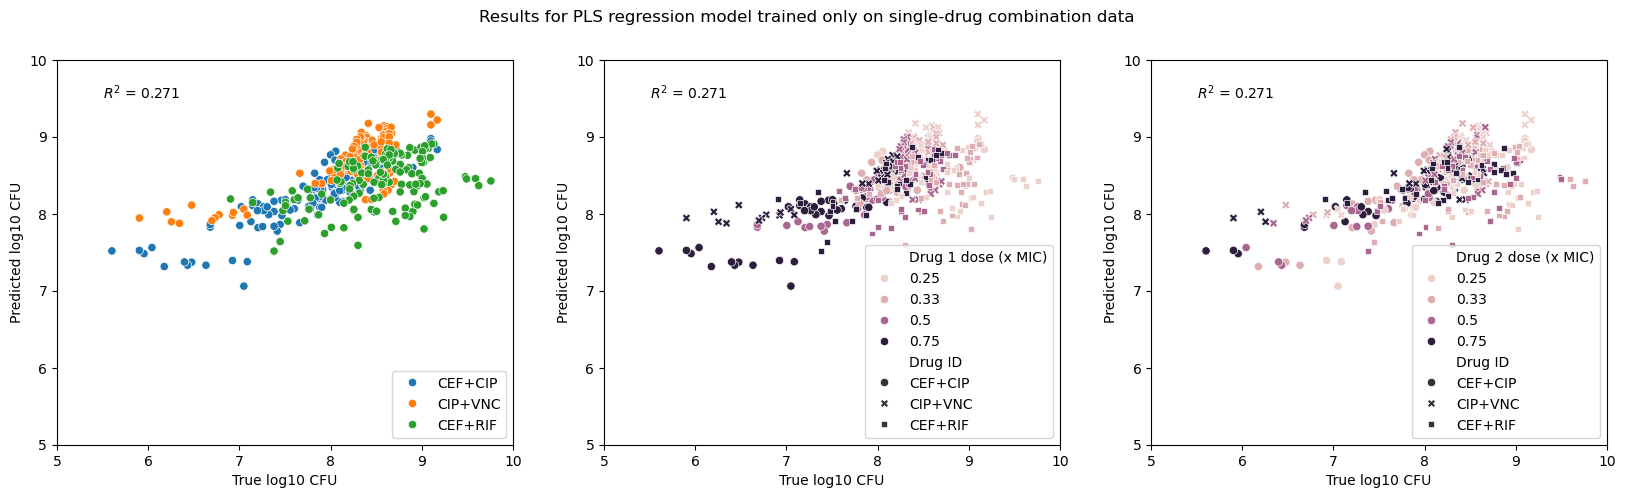

In [3]:
from src.train import train_with_custom_mask

single_mask = data_df["num_drugs"] == 1
combo_mask = data_df["num_drugs"] == 2

forward_model = train_with_custom_mask(
    df = data_df,
    train_mask = single_mask,
    test_mask = combo_mask,
    title = "Results for PLS regression model trained only on single-drug combination data"
)

Train on single-drug data + forward diagonal of combination matrix.

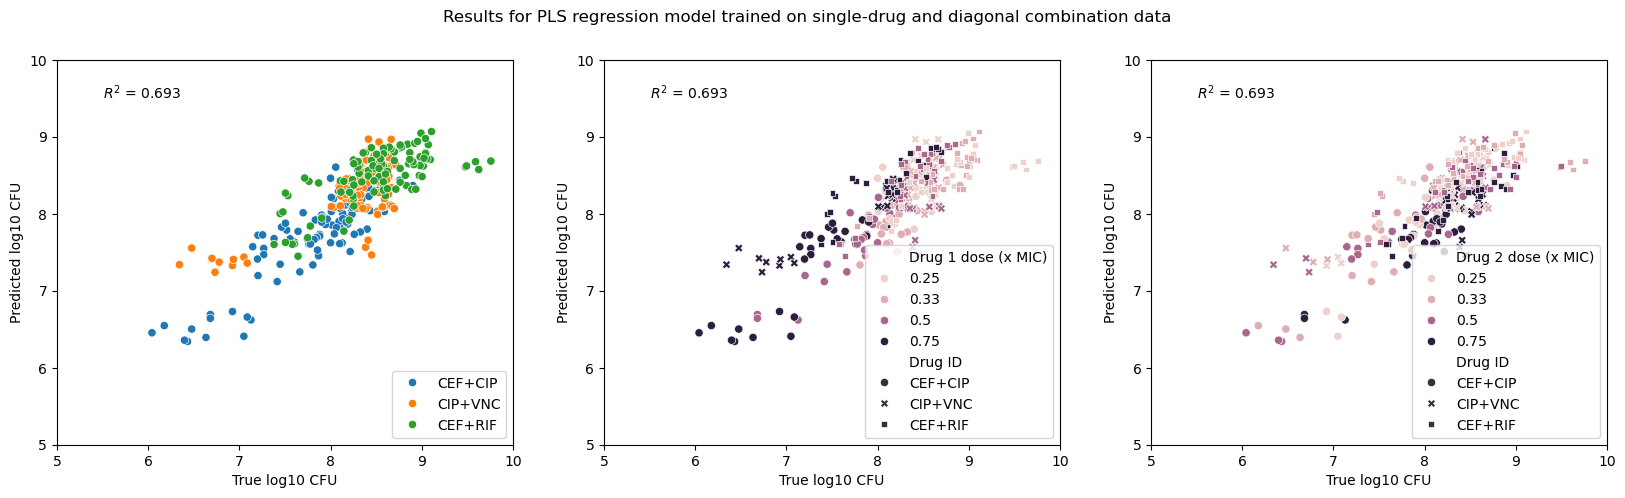

In [ ]:
forward_mask = (data_df["num_drugs"] == 1) | ((data_df["drug1_dose"]) == (data_df["drug2_dose"]))
forward_mask_complement = ~forward_mask

forward_model = train_with_custom_mask(
    df = data_df,
    train_mask = forward_mask,
    test_mask = forward_mask_complement,
    title = "Results for PLS regression model trained on single-drug and diagonal combination data"
)

Train on single-drug data and dose-swapped diagonal of combination matrix.

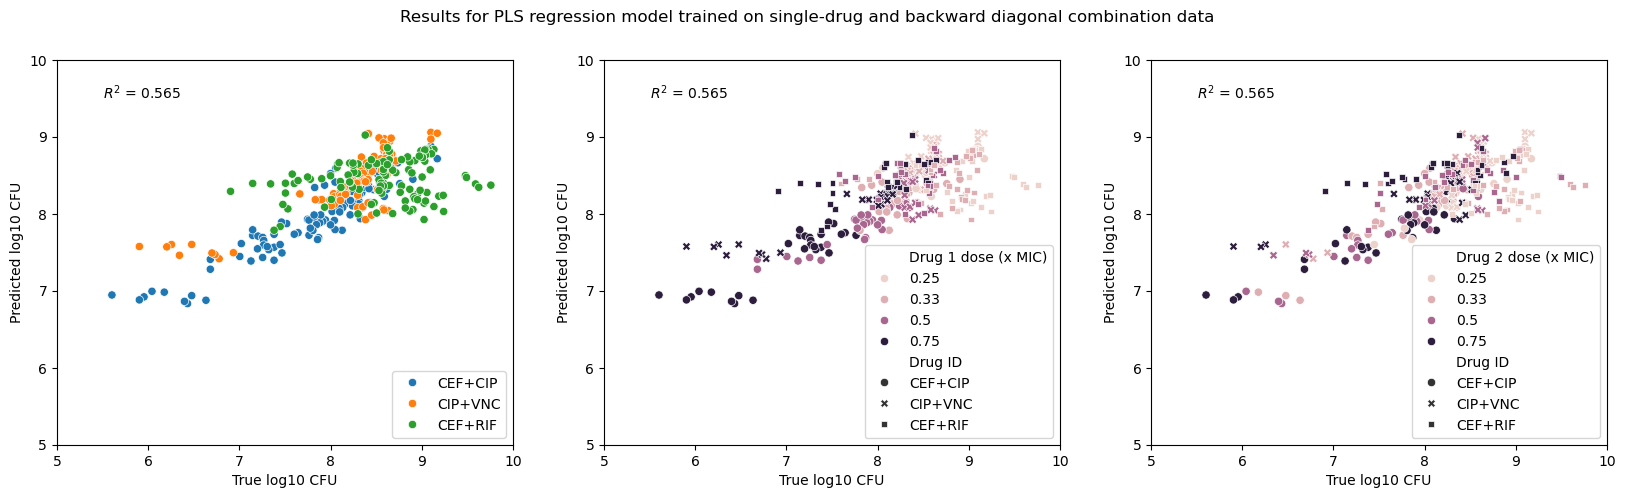

In [5]:
# Define mapping to cross doses
cross_dose_map = {
    0.25: 0.75,
    0.33: 0.50,
    0.50: 0.33,
    0.75: 0.25
}

# Map drug 1 dose to corresponding drug 2 dose, then generate boolean mask
mapped = np.array([cross_dose_map.get(dose, np.nan) for dose in data_df["drug1_dose"].to_numpy()])
backward_mask = data_df["drug2_dose"].to_numpy() == mapped
backward_mask = (data_df["num_drugs"] == 1) | backward_mask
backward_mask_complement = ~backward_mask

forward_model = train_with_custom_mask(
    df = data_df,
    train_mask = backward_mask,
    test_mask = backward_mask_complement,
    title = "Results for PLS regression model trained on single-drug and backward diagonal combination data"
)

## Training with successively more combination data

Implement a gradient of increasing combination data. Add 10 random combination datapoints along x-axis. Each point along the x-axis should contain X different splits, allowing for consistent evaluation. Then, show the mean and std of the R^2 on the y-axis for each datapoint. Look for a plateau of R^2. Then isolate that point and look at mechanistic underpinnings. (or look at importances over time??)

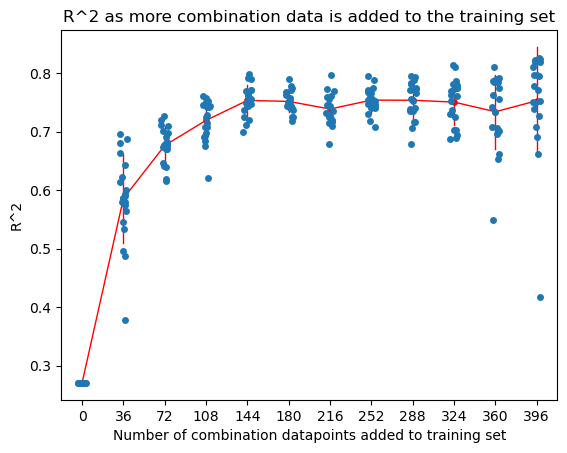

In [ ]:
from src.train import plot_r2_over_data_increase

plot_r2_over_data_increase(
    df = data_df,
    step_size = 36,
    n_splits = 20,
    seed = 111
)

## Optimizing necessary combinations (fixed test set)

Fixed test set mask.

In [14]:
# Define fixed test set mask
mask1 = (data_df["drug1_dose"] == 0.50) & (data_df["drug2_dose"] == 0.33)
mask2 = (data_df["drug1_dose"] == 0.75) & (data_df["drug2_dose"] == 0.33)
mask3 = (data_df["drug1_dose"] == 0.75) & (data_df["drug2_dose"] == 0.50)
mask4 = (data_df["drug1_dose"] == 0.33) & (data_df["drug2_dose"] == 0.50)
mask5 = (data_df["drug1_dose"] == 0.33) & (data_df["drug2_dose"] == 0.75) 
mask6 = (data_df["drug1_dose"] == 0.50) & (data_df["drug2_dose"] == 0.75) 

test_mask = mask1 | mask2 | mask3 | mask4 | mask5 | mask6

Train on diagonal.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",10
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


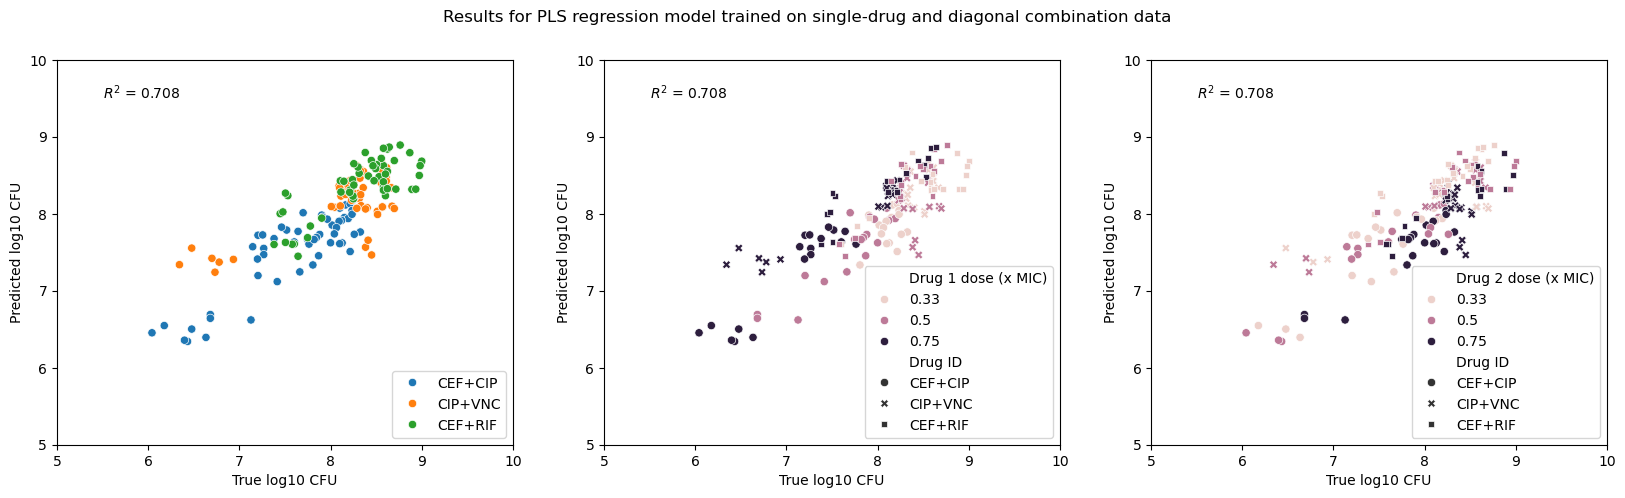

In [ ]:
train_with_custom_mask(
    df = data_df,
    train_mask = forward_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and diagonal combination data"
)

Train on first row.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",8
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


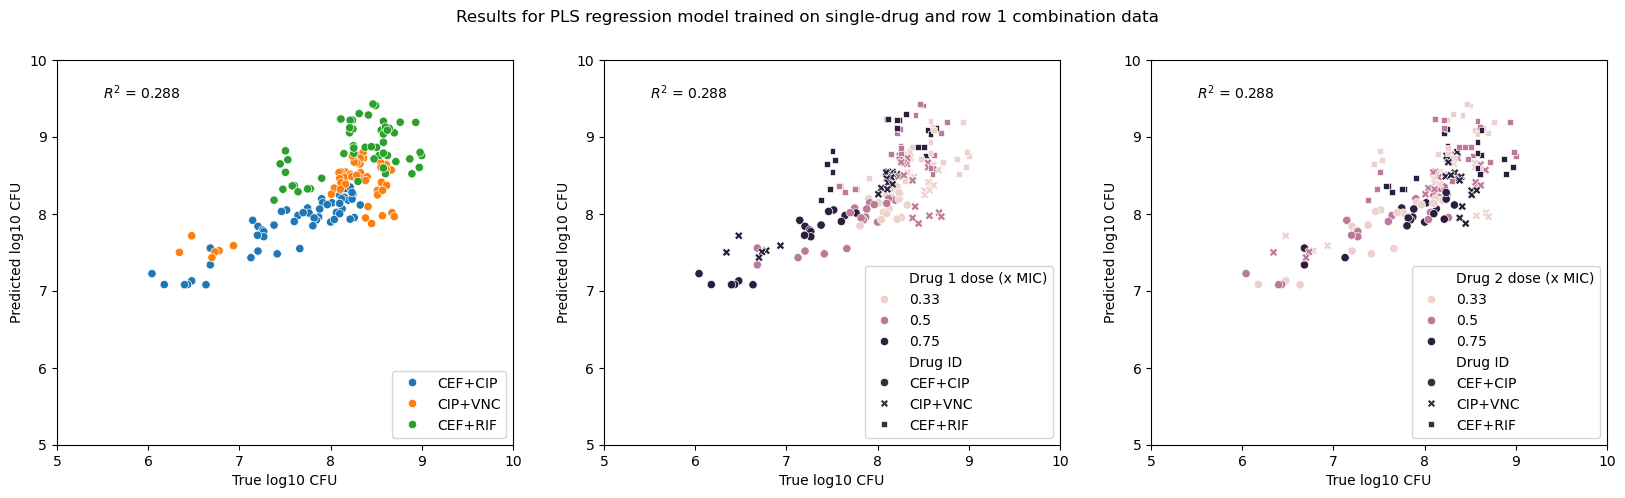

In [ ]:
row1_mask = (data_df["num_drugs"] == 1) | (data_df["drug1_dose"] == 0.25)

train_with_custom_mask(
    df = data_df,
    train_mask = row1_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and row 1 combination data"
)

Train on first column.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",10
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


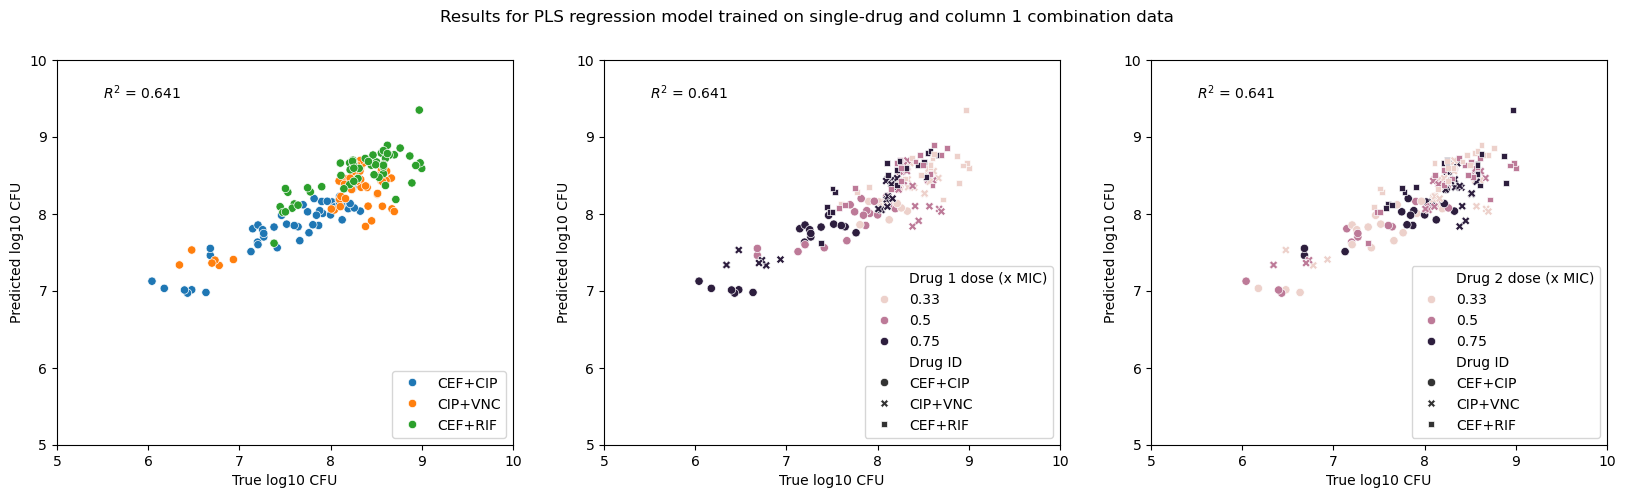

In [ ]:
col1_mask = (data_df["num_drugs"] == 1) | (data_df["drug2_dose"] == 0.25)

train_with_custom_mask(
    df = data_df,
    train_mask = col1_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and column 1 combination data"
)

Train on first column and row.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",7
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


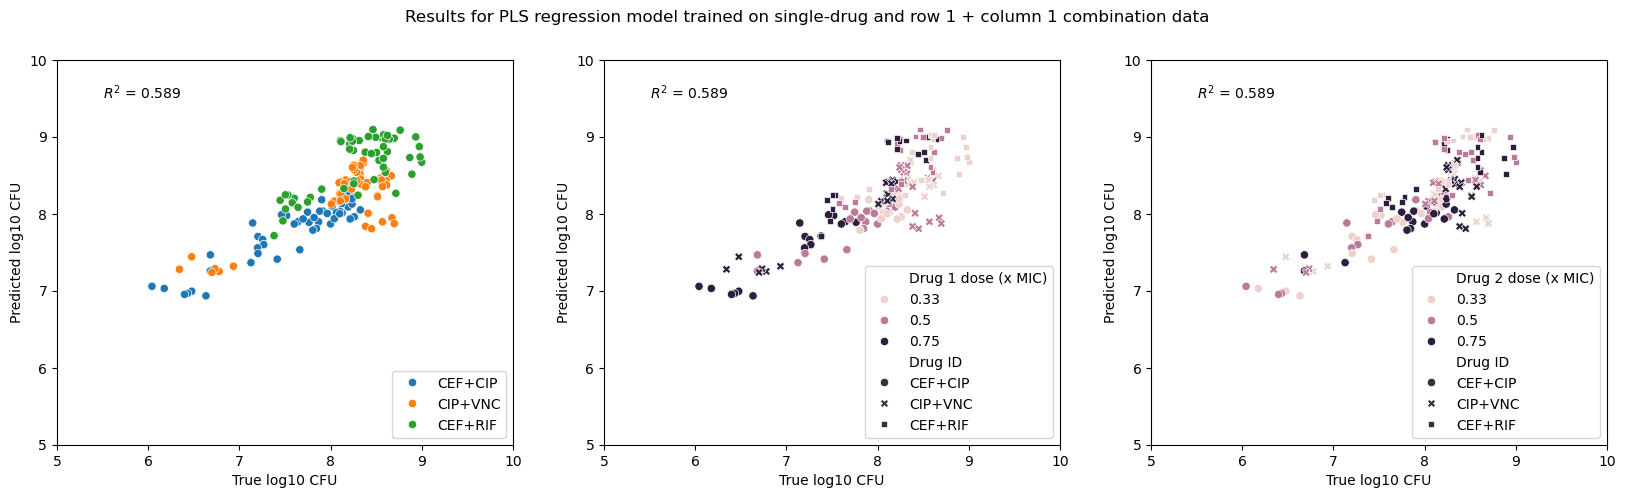

In [ ]:
t_mask = (data_df["num_drugs"] == 1) | (data_df["drug1_dose"] == 0.25) | (data_df["drug2_dose"] == 0.25)

train_with_custom_mask(
    df = data_df,
    train_mask = t_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and row 1 + column 1 combination data"
)

Train on first row and diagonal.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",8
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


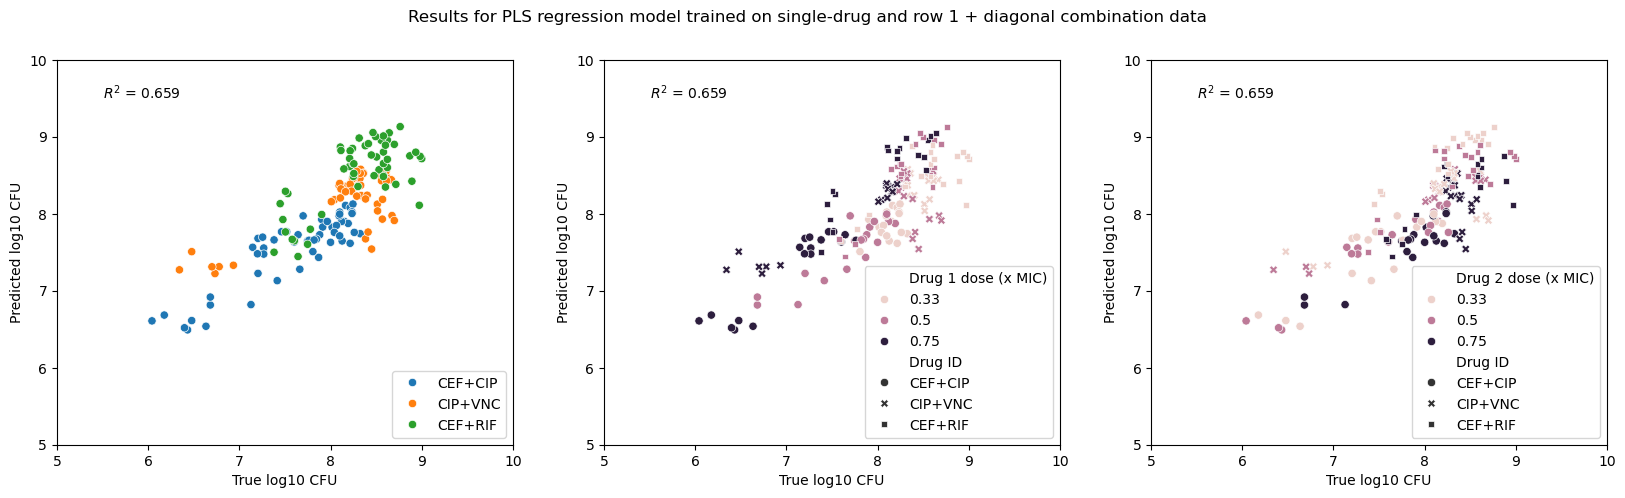

In [ ]:
row1_diag_mask = (data_df["num_drugs"] == 1) | (data_df["drug1_dose"] == 0.25) | ((data_df["drug1_dose"]) == (data_df["drug2_dose"]))

train_with_custom_mask(
    df = data_df,
    train_mask = row1_diag_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and row 1 + diagonal combination data"
)

Train on first column and diagonal.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",7
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


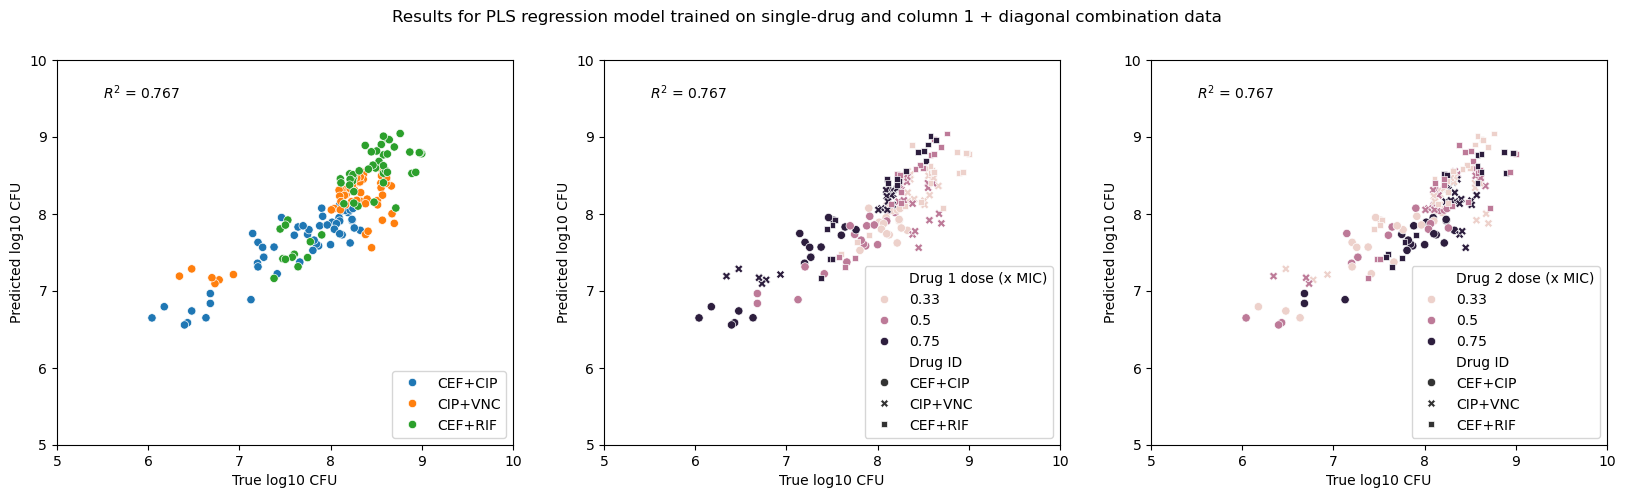

In [ ]:
col1_diag_mask = (data_df["num_drugs"] == 1) | (data_df["drug2_dose"] == 0.25) | ((data_df["drug1_dose"]) == (data_df["drug2_dose"]))

train_with_custom_mask(
    df = data_df,
    train_mask = col1_diag_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and column 1 + diagonal combination data"
)

Train on first row, first column, and diagonal.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",7
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06


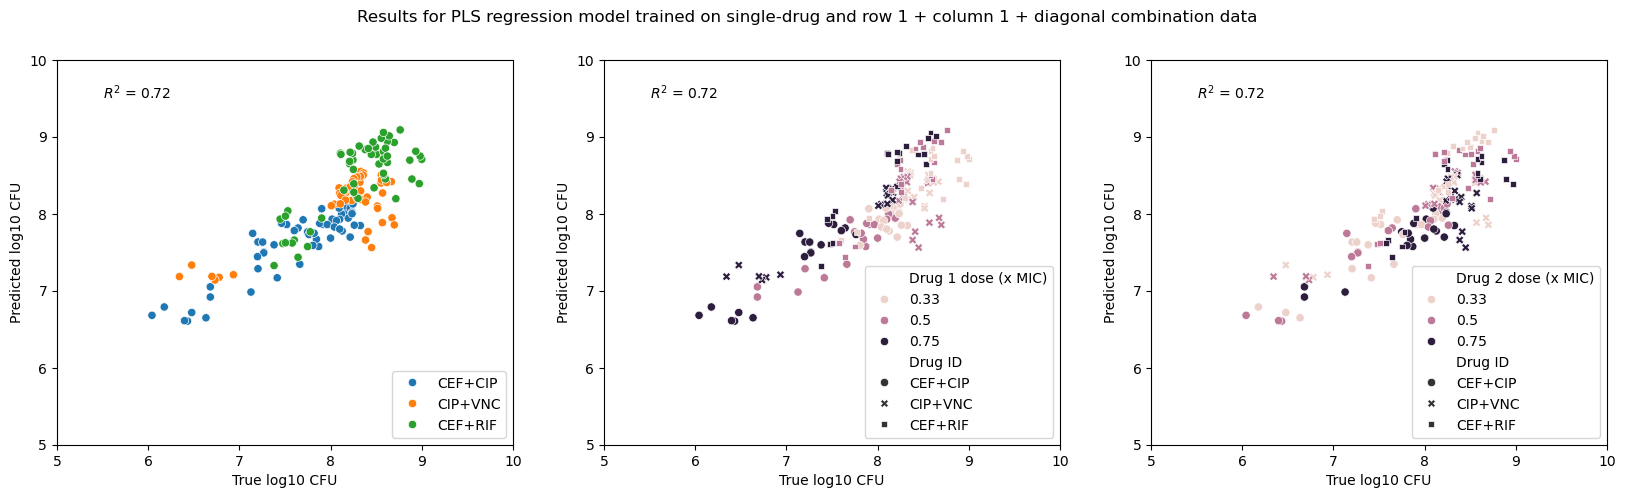

In [ ]:
all_mask = (data_df["num_drugs"] == 1) | (data_df["drug1_dose"] == 0.25)| (data_df["drug2_dose"] == 0.25) | ((data_df["drug1_dose"]) == (data_df["drug2_dose"]))

train_with_custom_mask(
    df = data_df,
    train_mask = all_mask,
    test_mask = test_mask,
    title = "Results for PLS regression model trained on single-drug and row 1 + column 1 + diagonal combination data"
)